In [ ]:
# Settings
data_dir = '/DATAPOOL/VPMB/BIDS-VPMB-SPE'
space_label = "MNI152NLin2009cAsym"
derivatives_folder = "derivatives/fmriprep23/fmriprep"
task_label = "loc"
smoothing_fwhm = 6.0
high_pass_hz = 0.03

In [1]:
# import first level data automatically from fmriPrep derivatives
from nilearn.glm.first_level import first_level_from_bids

(
    models,
    models_run_imgs,
    models_events,
    models_confounds,
) = first_level_from_bids(
    data_dir,
    task_label,
    space_label,
    hrf_model="spm",
    smoothing_fwhm=smoothing_fwhm,
    high_pass=high_pass_hz,
    n_jobs=12,
    derivatives_folder=derivatives_folder,
)

/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/glm/first_level/first_level.py:1029: UserWarning: 'slice_time_ref' provided (0.0) is different from the value found in the BIDS dataset (0.455).
Note this may lead to the wrong model specification.
  warn(f"'slice_time_ref' provided ({slice_time_ref}) is different "


In [14]:
# fetch data for subject 1
model, imgs, events, all_confounds = (
    models[0],
    models_run_imgs[0],
    models_events[0],
    models_confounds[0],
)
subject = f"sub-{model.subject_label}"
model.minimize_memory = False  # override default

In [16]:
# trim confounds
confounds = all_confounds[0][['csf','white_matter','trans_x','trans_y','trans_z','rot_x','rot_y','rot_z']]
confounds

,csf,white_matter,trans_x,trans_y,trans_z,rot_x,rot_y,rot_z
0,19358.292792,12101.883870,0.067942,0.000174,-0.039653,-0.000184,-0.001120,-0.002106
1,18960.095641,12073.462479,0.040673,-0.039992,-0.064136,0.000394,-0.000880,-0.002226
2,18753.049895,12074.171976,0.024235,-0.066625,-0.087941,0.000679,-0.000755,-0.002243
3,18751.529733,12084.414595,0.059825,0.079324,-0.002095,-0.000281,-0.000837,-0.002024
4,18641.731094,12072.380803,0.039638,0.029772,-0.014865,-0.000013,-0.000697,-0.001714
...,...,...,...,...,...,...,...,...
169,18495.201905,12006.196886,-0.021878,0.089709,-0.025389,0.000473,0.002257,0.002765
170,18422.786488,12014.608034,-0.033881,-0.042209,-0.079804,0.001344,0.002471,0.002825
171,18467.898903,12051.948979,-0.024932,0.068447,-0.038554,0.000625,0.002352,0.002855
172,18475.030623,12040.013047,-0.030643,0.108789,-0.025230,0.000174,0.002375,0.002765


In [18]:
# Fit and contrasts
model.fit(imgs, events, confounds)

z_map = model.compute_contrast("MovingPlaid - StaticPlaid")

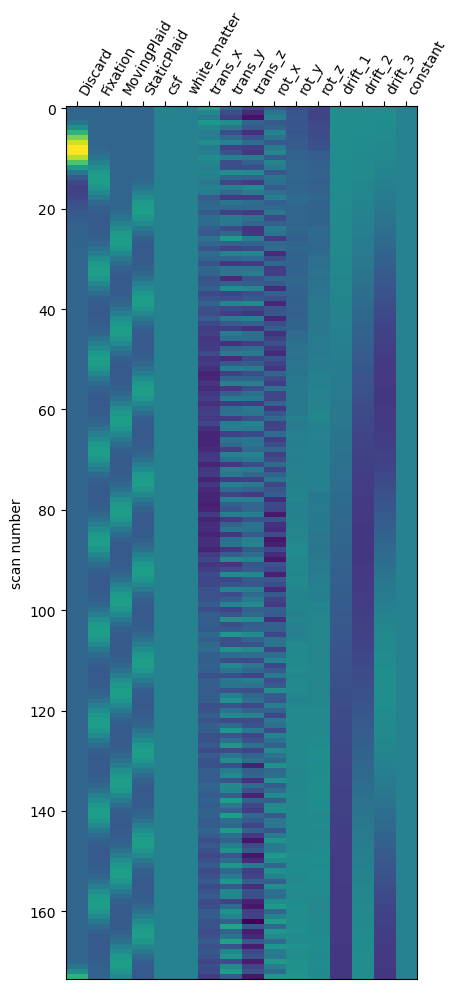

In [20]:
# check design matrix
design_matrix = model.design_matrices_[0]

import matplotlib.pyplot as plt
from nilearn.plotting import plot_design_matrix

plot_design_matrix(design_matrix,rescale=True)

plt.show()

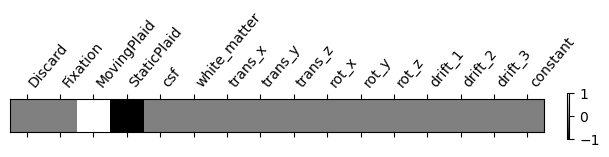

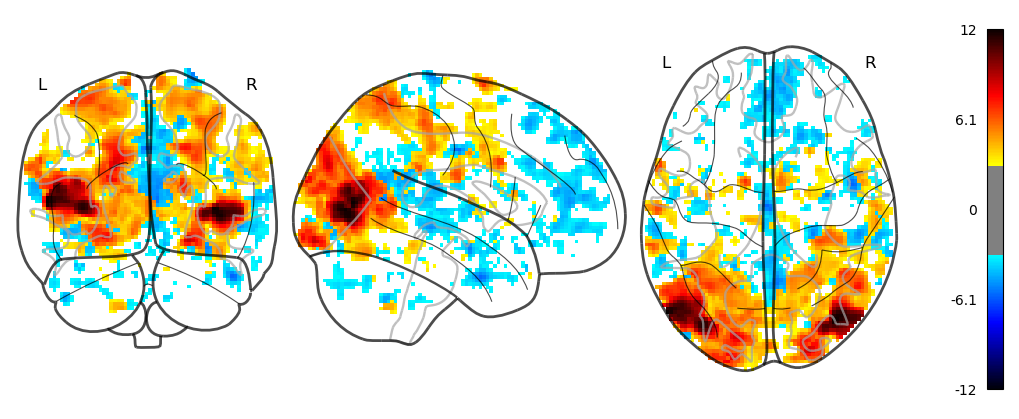

In [26]:
# Show map
import matplotlib.pyplot as plt
from nilearn import plotting
from scipy.stats import norm
from nilearn.plotting import plot_contrast_matrix

plot_contrast_matrix("MovingPlaid - StaticPlaid", design_matrix, colorbar=True)
plotting.plot_glass_brain(
    z_map,
    colorbar=True,
    threshold=norm.isf(0.001),
    plot_abs=False,
    display_mode="ortho",
    figure=plt.figure(figsize=(10, 4)),
)
plt.show()

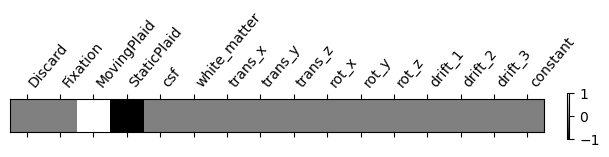

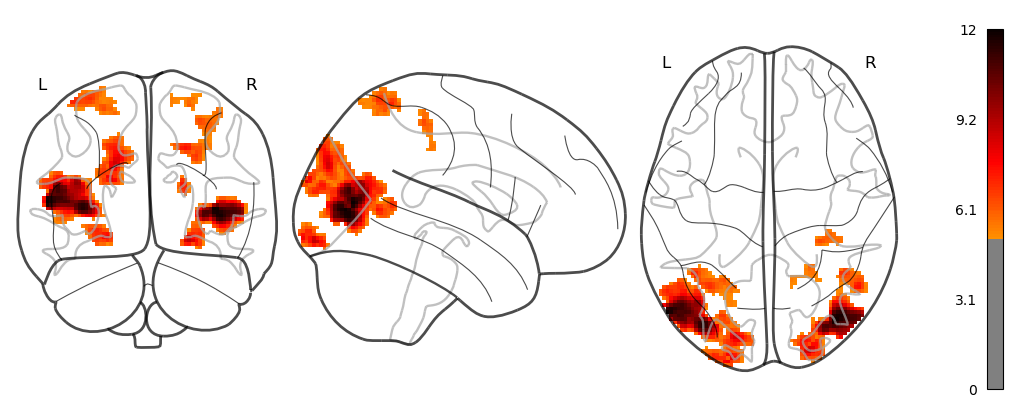

In [27]:
# Show thresholded map
from nilearn.glm import threshold_stats_img

clean_map, threshold = threshold_stats_img(
    z_map, alpha=0.05, height_control="bonferroni", cluster_threshold=50
)

plot_contrast_matrix("MovingPlaid - StaticPlaid", design_matrix, colorbar=True)
plotting.plot_glass_brain(
    clean_map,
    colorbar=True,
    threshold=threshold,
    plot_abs=False,
    display_mode="ortho",
    figure=plt.figure(figsize=(10, 4)),
)
plt.show()

plt.savefig('nilearn-bids.png')

In [28]:
# Export cluster table
from nilearn.reporting import get_clusters_table

table = get_clusters_table(z_map, threshold, 50)
print(table.to_latex())

\begin{tabular}{llrrrrl}
\toprule
{} & Cluster ID &     X &      Y &     Z &  Peak Stat & Cluster Size (mm3) \\
\midrule
0  &          1 & -56.5 &  -74.5 &   9.5 &  12.234816 &               9928 \\
1  &         1a & -36.5 &  -80.5 &   5.5 &  11.666266 &                    \\
2  &         1b & -50.5 &  -76.5 &  15.5 &  11.243649 &                    \\
3  &         1c & -40.5 &  -68.5 &  19.5 &   9.760499 &                    \\
4  &          2 &  37.5 &  -78.5 &   5.5 &  12.167968 &               5728 \\
5  &         2a &  51.5 &  -60.5 &   5.5 &   7.491974 &                    \\
6  &         2b &  43.5 &  -52.5 &   7.5 &   6.943002 &                    \\
7  &          3 &  23.5 &  -96.5 & -12.5 &   8.828203 &                840 \\
8  &          4 & -18.5 &  -88.5 &  31.5 &   8.548792 &               3456 \\
9  &         4a & -20.5 & -100.5 &  21.5 &   8.196729 &                    \\
10 &         4b & -24.5 &  -76.5 &  25.5 &   6.741569 &                    \\
11 &          5 & -22

/tmp/ipykernel_66620/3773546554.py:5: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(table.to_latex())


/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/interfaces/bids/_utils.py:51: UserWarning: Contrast name "MovingPlaid - StaticPlaid" changed to "movingplaidMinusStaticplaid"
  warnings.warn(
/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/interfaces/bids/_utils.py:51: UserWarning: Contrast name "MovingPlaid - StaticPlaid" changed to "movingplaidMinusStaticplaid"
  warnings.warn(


Extracting and saving residuals
Extracting and saving r_square


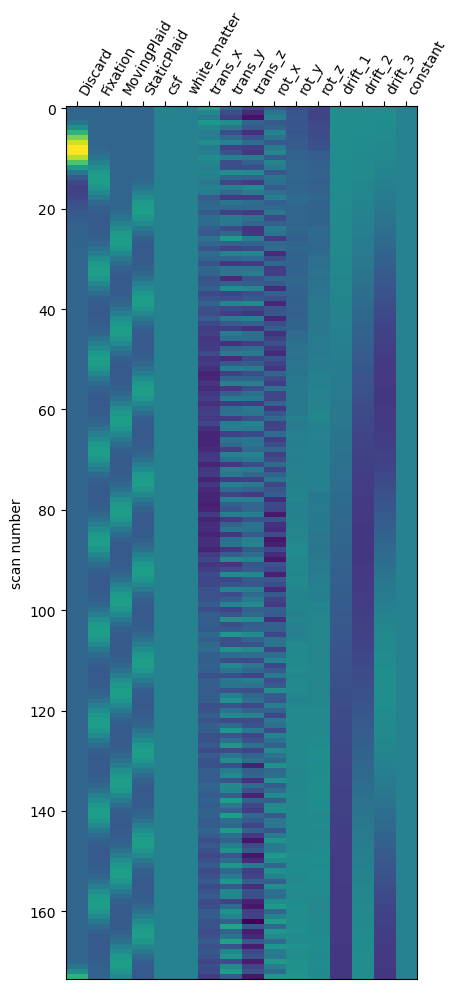

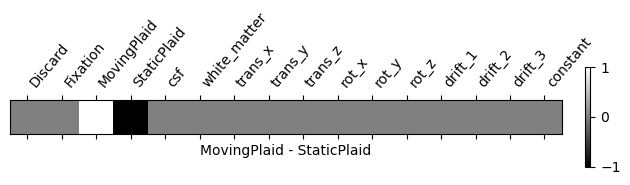

In [33]:
# save model to disk
import os
from nilearn.interfaces.bids import save_glm_to_bids

save_glm_to_bids(
    model,
    contrasts="MovingPlaid - StaticPlaid",
    contrast_types={"MovingPlaid - StaticPlaid": "t"},
    out_dir=os.path.join(data_dir,"derivatives","nilearn_glm"),
    prefix=f"{subject}_task-{task_label}",
)